## LeNet Architecture

In [1]:
# Image Size ( 32*32*1) : GreyScale image of channel 1 
# 1st Convolution Layer : 6 filters & size 5*5 & stride =1
# 1st Pooling layer : size : 2*2 , filters 6 & stide = 2 
# 2nd Convolution Layer : 16 filters , 5*5 , stride = 1
# 2nd Pooling Layer : 2*2 , stride = 2 & filters = 16,
# Flatten : 400 neurons input layer 
# Dense Layer 1 : 120 nodes
# Dense layer 2 : 84 nodes
# Output Layer : 10 nodes (Num from 0 to 9)

In [ ]:
# Activation Function Used : Tanh ( output range -1 to 1)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Loading the MNIST Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

## Sample Data

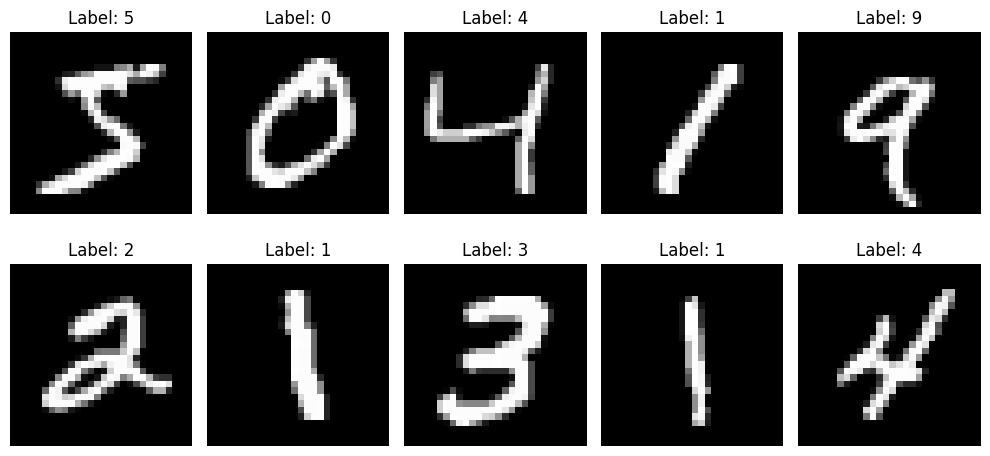

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Normalize the image

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Reshape Images

In [8]:
x_train = x_train.reshape((60000, 28, 28, 1)) ## CNN wants height , width , channels
x_test = x_test.reshape((10000, 28, 28, 1))

In [9]:
model = models.Sequential()

## Layer 1 : First Convolution layer

In [10]:
model.add(
    layers.Conv2D(
        filters=6,
        kernel_size=(5,5),
        activation='tanh',
        input_shape=(28,28,1)
    )
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Layer 2 : Pooling layer (Average Pooling)

In [11]:
model.add(
    layers.AveragePooling2D(pool_size=(2,2))
)

## Layer 3 : 2nd Conv Layer

In [12]:
model.add(
    layers.Conv2D(
        filters=16,
        kernel_size=(5,5),
        activation='tanh'
    )
)

## Layer 2 : 2nd Pooling layer

model.add(
    layers.AveragePooling2D(pool_size=(2,2))
)

## Layer 5 : Flattened Layer

In [14]:
model.add(layers.Flatten())

## Dense Layer

In [15]:
model.add(
    layers.Dense(
        120,
        activation='tanh'
    )
)

In [16]:
model.add(
    layers.Dense(
        84,
        activation='tanh'
    )
)

## Output Layer

In [17]:
model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model training

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9112 - loss: 0.3024 - val_accuracy: 0.9638 - val_loss: 0.1184
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9664 - loss: 0.1102 - val_accuracy: 0.9777 - val_loss: 0.0745
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9779 - loss: 0.0725 - val_accuracy: 0.9827 - val_loss: 0.0602
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9827 - loss: 0.0541 - val_accuracy: 0.9840 - val_loss: 0.0522
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9861 - loss: 0.0428 - val_accuracy: 0.9822 - val_loss: 0.0580
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9883 - loss: 0.0359 - val_accuracy: 0.9843 - val_loss: 0.0566
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9904 - loss: 0.0291 - val_accuracy: 0.9860 - val_loss: 0.0536
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0233 - val_accuracy: 0.

## Model Accuracy

In [21]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9833 - loss: 0.0524


## Making Predictions

In [22]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


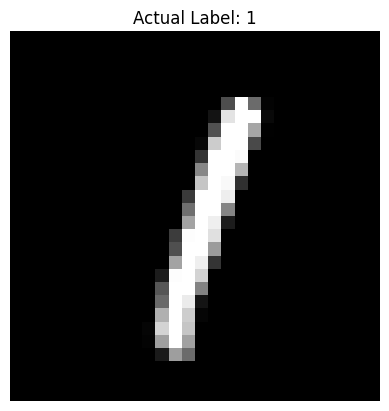

Predicted Label: 1


In [23]:
index = 5

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Label: {}".format(y_test[index]))
plt.axis('off')
plt.show()

predicted_label = np.argmax(predictions[index])

print("Predicted Label:", predicted_label)

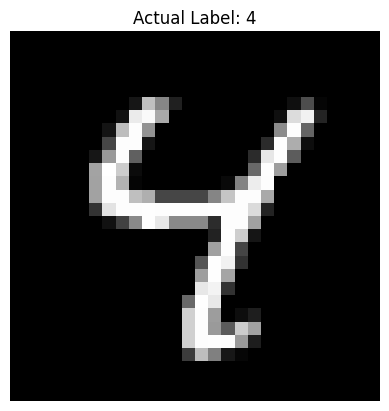

Predicted Label: 4


In [24]:
index = 6

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Actual Label: {}".format(y_test[index]))
plt.axis('off')
plt.show()

predicted_label = np.argmax(predictions[index])

print("Predicted Label:", predicted_label)

## Accuracy Plot

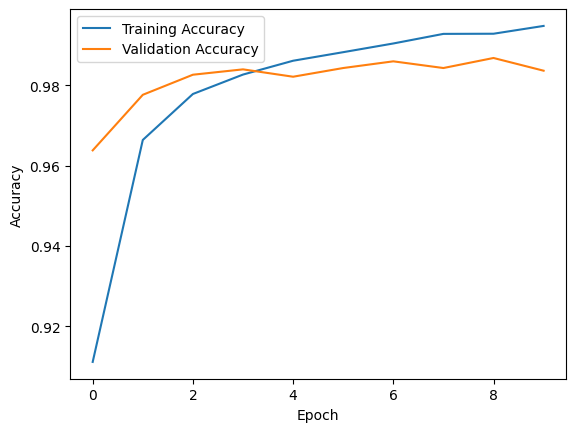

In [25]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()